# Phase 2 — Caractérisation quantitative des traits tonaux

**Entrée** : `features_trilingue.csv` (généré par le notebook Phase 1)

## 0. Imports

In [ ]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from scipy import stats
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.decomposition import PCA
from sklearn.inspection import permutation_importance
from pathlib import Path

# ── Chemins ───────────────────────────────────────────────────────────────────
CSV_FEATURES = Path('../results/01_acoustic_analysis/features_trilingue.csv')
DOSSIER_FIG  = Path('../results/02_quantitative_analysis/figures')
DOSSIER_FIG.mkdir(parents=True, exist_ok=True)

# ── Style matplotlib ──────────────────────────────────────────────────────────
DARK_BG  = '#0D1117'
AX_BG    = '#161B22'
GRID_COL = '#30363D'
COULEURS = {'fongbe': '#E8593C', 'wolof': '#378ADD', 'swahili': '#1D9E75'}
LANGUES  = ['fongbe', 'wolof', 'swahili']
LABELS   = {'fongbe': 'Fongbé (tonal)', 'wolof': 'Wolof (faib. tonal)', 'swahili': 'Swahili (non tonal)'}

def style_ax(ax, title='', xlabel='', ylabel=''):
    ax.set_facecolor(AX_BG)
    ax.tick_params(colors='white', labelsize=8)
    for sp in ax.spines.values(): sp.set_edgecolor(GRID_COL)
    ax.grid(axis='y', color=GRID_COL, linewidth=0.4, alpha=0.7)
    if title:  ax.set_title(title, color='white', fontsize=9, pad=6)
    if xlabel: ax.set_xlabel(xlabel, color='white', fontsize=8)
    if ylabel: ax.set_ylabel(ylabel, color='white', fontsize=8)

def sauver(fig, nom):
    path = DOSSIER_FIG / nom
    fig.savefig(str(path), facecolor=DARK_BG, bbox_inches='tight', dpi=150)
    print(f'  Figure → {path}')

print(' Imports et configuration')

 Imports et configuration


## 1. Chargement des features

In [8]:
df = pd.read_csv(CSV_FEATURES, encoding='utf-8-sig')

# Colonnes F0 (5 métriques du sujet)
COLS_F0 = ['f0_mean', 'f0_std', 'f0_range_hz', 'f0_range_st',
           'f0_slope_hz_per_ms', 'n_inflexions_per_sec', 'voiced_ratio']

# Colonnes MFCC (13 moyennes)
COLS_MFCC = [f'mfcc_{i:02d}_mean' for i in range(1, 14)]

# Vecteur 18 dim pour le SVM (sujet) : 13 MFCC + 5 métriques F0
COLS_SVM = COLS_MFCC + ['f0_mean', 'f0_std', 'f0_range_hz',
                         'f0_slope_hz_per_ms', 'n_inflexions_per_sec']

print(f'Features chargées : {len(df)} énoncés × {len(df.columns)} colonnes')
print(f'Langues : {df["langue"].value_counts().to_dict()}')
print(f'\nColonnes F0 disponibles : {[c for c in COLS_F0 if c in df.columns]}')
print(f'Colonnes MFCC disponibles : {len([c for c in COLS_MFCC if c in df.columns])}/13')

df.groupby('langue')[COLS_F0[:4]].describe().round(2)

Features chargées : 100 énoncés × 29 colonnes
Langues : {'wolof': 35, 'swahili': 35, 'fongbe': 30}

Colonnes F0 disponibles : ['f0_mean', 'f0_std', 'f0_range_hz', 'f0_range_st', 'f0_slope_hz_per_ms', 'n_inflexions_per_sec', 'voiced_ratio']
Colonnes MFCC disponibles : 13/13


f0_mean                                                        f0_std  \
          count    mean    std     min     25%     50%     75%     max  count   
langue                                                                          
fongbe     30.0  231.83  24.37  184.05  214.55  228.33  242.84  283.09   30.0   
swahili    35.0  187.64  44.78  105.97  144.85  197.78  217.26  285.82   35.0   
wolof      35.0  157.99  46.54   82.50  124.50  148.30  191.06  261.25   35.0   

                ... f0_range_hz         f0_range_st                          \
          mean  ...         75%     max       count   mean   std  min   25%   
langue          ...                                                           
fongbe   39.26  ...      183.78  245.58        30.0   9.95  3.82  1.2  7.25   
swahili  26.56  ...      173.78  290.10        35.0  12.15  4.62  5.6  9.40   
wolof    26.73  ...      165.21  259.96        35.0  12.01  6.00  2.4  7.45   

                            
          50%    75%   max  
langue                      
fongbe   10.4  12.42  17.1  
swahili  10.9  14.05  27.4  
wolof     9.4  16.75  23.6  

[3 rows x 32 columns]

## 2.1 Tableau comparatif des statistiques F0

In [10]:
# ── Tableau comparatif complet ────────────────────────────────────────────────
metriques_labels = {
    'f0_mean':              'F0 moyenne (Hz)',
    'f0_std':               'F0 écart-type (Hz)  ← variabilité intra-énoncé',
    'f0_range_hz':          'F0 range (Hz)',
    'f0_range_st':          'F0 range (demi-tons)',
    'f0_slope_hz_per_ms':   'Pente F0 moyenne (Hz/ms)',
    'n_inflexions_per_sec': 'Inflexions F0 par seconde',
    'voiced_ratio':         'Ratio voisé',
}

rows = []
for col, label in metriques_labels.items():
    if col not in df.columns:
        continue
    row = {'Métrique': label}
    for lang in LANGUES:
        vals = df[df['langue'] == lang][col].dropna()
        row[lang.capitalize()] = f'{vals.mean():.2f} ± {vals.std():.2f}'
    rows.append(row)

df_tableau = pd.DataFrame(rows).set_index('Métrique')
df_tableau.columns = ['Fongbé (tonal)', 'Wolof (faib. tonal)', 'Swahili (non tonal)']

print('Tableau comparatif F0 — moyenne ± écart-type\n')
print(df_tableau.to_string())

# Export CSV pour le rapport
df_tableau.to_csv(DOSSIER_FIG / 'tableau_f0_comparatif.csv', encoding='utf-8-sig')
print('\n Tableau exporté → figures_phase2/tableau_f0_comparatif.csv')

Tableau comparatif F0 — moyenne ± écart-type

                                                Fongbé (tonal) Wolof (faib. tonal) Swahili (non tonal)
Métrique                                                                                              
F0 moyenne (Hz)                                 231.83 ± 24.37      157.99 ± 46.54      187.64 ± 44.78
F0 écart-type (Hz)  ← variabilité intra-énoncé   39.26 ± 17.97       26.73 ± 22.80       26.56 ± 14.30
F0 range (Hz)                                   140.51 ± 59.81      114.29 ± 73.84      129.73 ± 62.38
F0 range (demi-tons)                               9.95 ± 3.82        12.01 ± 6.00        12.15 ± 4.62
Pente F0 moyenne (Hz/ms)                          -0.02 ± 0.16        -0.01 ± 0.06        -0.01 ± 0.01
Inflexions F0 par seconde                          9.06 ± 4.22        11.70 ± 5.05        16.16 ± 2.53
Ratio voisé                                        0.51 ± 0.19         0.44 ± 0.17         0.78 ± 0.06

 Tableau exporté → figures

## 2.2 Box plots F0 par langue

  Figure → figures_phase2/boxplots_f0_5metriques.png


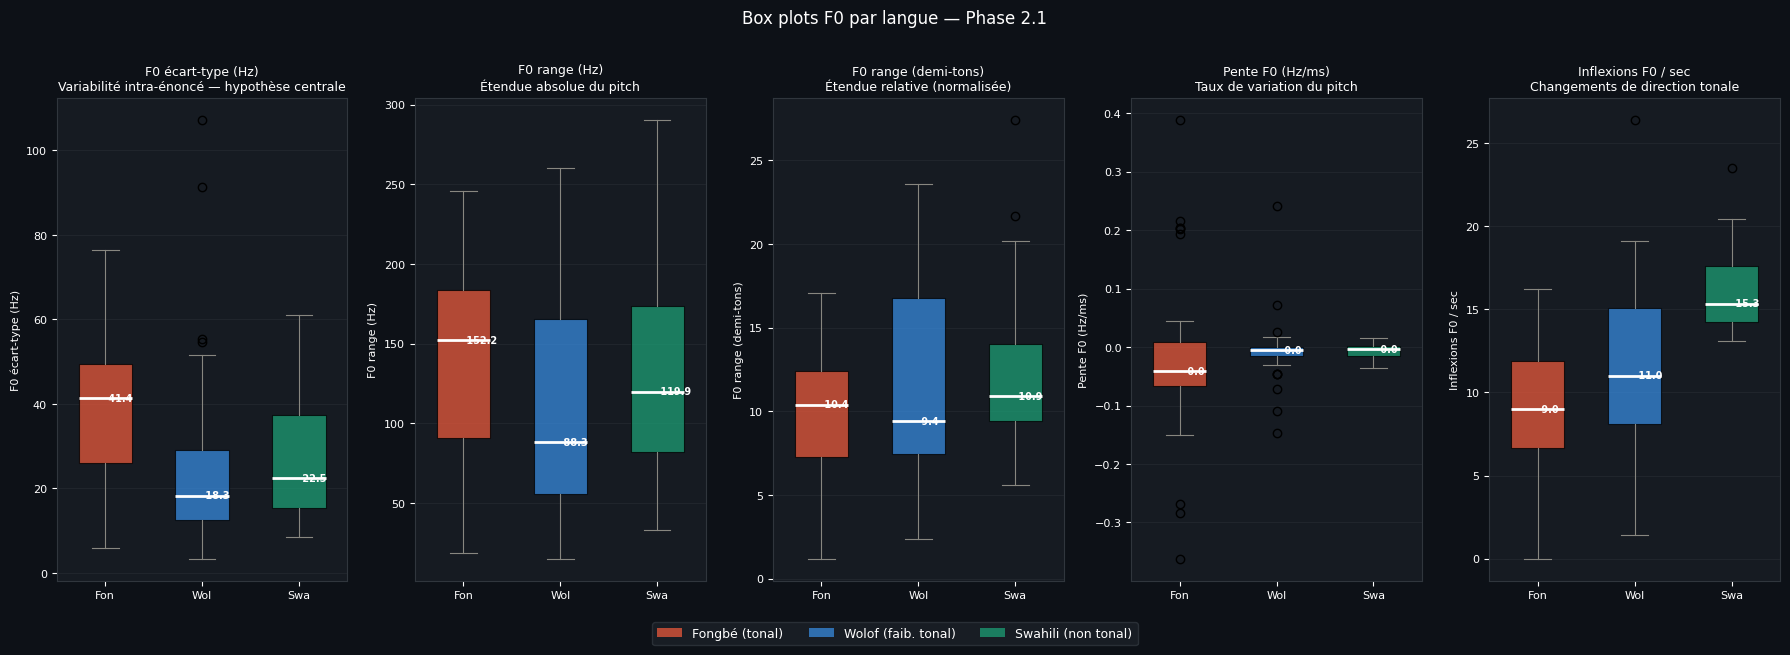

In [11]:
metriques_plot = [
    ('f0_std',               'F0 écart-type (Hz)',       'Variabilité intra-énoncé — hypothèse centrale'),
    ('f0_range_hz',          'F0 range (Hz)',             'Étendue absolue du pitch'),
    ('f0_range_st',          'F0 range (demi-tons)',      'Étendue relative (normalisée)'),
    ('f0_slope_hz_per_ms',   'Pente F0 (Hz/ms)',          'Taux de variation du pitch'),
    ('n_inflexions_per_sec', 'Inflexions F0 / sec',       'Changements de direction tonale'),
]

fig, axes = plt.subplots(1, 5, figsize=(18, 6))
fig.patch.set_facecolor(DARK_BG)
fig.suptitle('Box plots F0 par langue — Phase 2.1', color='white', fontsize=12, y=1.01)
plt.subplots_adjust(wspace=0.35)

for ax, (col, ylabel, note) in zip(axes, metriques_plot):
    if col not in df.columns:
        ax.text(0.5, 0.5, f'{col}\nmanquant', transform=ax.transAxes,
                ha='center', va='center', color='white')
        continue

    data  = [df[df['langue'] == l][col].dropna() for l in LANGUES]
    bp    = ax.boxplot(data, patch_artist=True, widths=0.55,
                       medianprops=dict(color='white', linewidth=2))

    for patch, lang in zip(bp['boxes'], LANGUES):
        patch.set_facecolor(COULEURS[lang])
        patch.set_alpha(0.75)
        patch.set_linewidth(0.8)
    for element in ['whiskers', 'caps', 'fliers']:
        plt.setp(bp[element], color='#888780', linewidth=0.8)

    # Médiane annotée
    for i, (lang, d) in enumerate(zip(LANGUES, data), 1):
        med = d.median()
        ax.text(i, med, f' {med:.1f}', color='white', fontsize=7,
                va='center', fontweight='bold')

    ax.set_xticks([1, 2, 3])
    ax.set_xticklabels(['Fon', 'Wol', 'Swa'], color='white', fontsize=9)
    style_ax(ax, title=f'{ylabel}\n{note}', ylabel=ylabel)

# Légende
patches = [mpatches.Patch(facecolor=COULEURS[l], label=LABELS[l], alpha=0.75)
           for l in LANGUES]
fig.legend(handles=patches, loc='lower center', ncol=3,
           facecolor='#1C2128', edgecolor=GRID_COL,
           labelcolor='white', fontsize=9, bbox_to_anchor=(0.5, -0.06))

plt.tight_layout()
sauver(fig, 'boxplots_f0_5metriques.png')
plt.show()

## 2.3 Test statistique de l'hypothèse

In [12]:
print('═' * 60)
print('  TEST DE L\'HYPOTHÈSE — variabilité F0 intra-énoncé (f0_std)')
print('═' * 60)

# Extraire les valeurs par langue
vals = {l: df[df['langue'] == l]['f0_std'].dropna().values for l in LANGUES}

print(f'\nMoyennes f0_std :')
for l in LANGUES:
    print(f'  {l:<10} : {vals[l].mean():.2f} Hz  (n={len(vals[l])})')

# ── Test de Kruskal-Wallis ────────────────────────────────────────────────────
H, p_kruskal = stats.kruskal(*[vals[l] for l in LANGUES])
print(f'\nKruskal-Wallis : H = {H:.3f}, p = {p_kruskal:.4f}')
if p_kruskal < 0.05:
    print('  → Différence significative entre les 3 langues (p < 0.05) ')
else:
    print('  → Pas de différence significative (p ≥ 0.05) ')

# ── Tests post-hoc Mann-Whitney (comparaisons par paires) ────────────────────
print('\nTests Mann-Whitney post-hoc (correction Bonferroni, α/3 = 0.017) :')
paires = [('fongbe', 'wolof'), ('fongbe', 'swahili'), ('wolof', 'swahili')]
for l1, l2 in paires:
    U, p = stats.mannwhitneyu(vals[l1], vals[l2], alternative='two-sided')
    sig = ' sig.' if p < 0.017 else '  ns'
    print(f'  {l1:<10} vs {l2:<10} : U={U:.0f}, p={p:.4f}  {sig}')

# ── Taille d'effet (Cohen's d) ────────────────────────────────────────────────
print('\nTaille d\'effet Cohen\'s d :')
for l1, l2 in paires:
    v1, v2 = vals[l1], vals[l2]
    pooled = np.sqrt((v1.std()**2 + v2.std()**2) / 2)
    d = (v1.mean() - v2.mean()) / pooled if pooled > 0 else 0
    interp = 'grand' if abs(d) > 0.8 else ('moyen' if abs(d) > 0.5 else 'petit')
    print(f'  {l1:<10} vs {l2:<10} : d = {d:.2f}  ({interp})')

print('\n' + '═' * 60)
print('  CONCLUSION')
print('═' * 60)
gradient_ok = vals['fongbe'].mean() > vals['wolof'].mean() > vals['swahili'].mean()
if gradient_ok:
    print('  Gradient fongbé > wolof > swahili CONFIRMÉ sur f0_std ')
else:
    ranking = sorted(LANGUES, key=lambda l: vals[l].mean(), reverse=True)
    print(f'  Gradient observé : {" > ".join(ranking)}')
    print('  Gradient attendu NON confirmé — voir analyse critique ')

════════════════════════════════════════════════════════════
  TEST DE L'HYPOTHÈSE — variabilité F0 intra-énoncé (f0_std)
════════════════════════════════════════════════════════════

Moyennes f0_std :
  fongbe     : 39.26 Hz  (n=30)
  wolof      : 26.73 Hz  (n=35)
  swahili    : 26.56 Hz  (n=35)

Kruskal-Wallis : H = 12.059, p = 0.0024
  → Différence significative entre les 3 langues (p < 0.05) 

Tests Mann-Whitney post-hoc (correction Bonferroni, α/3 = 0.017) :
  fongbe     vs wolof      : U=754, p=0.0026   sig.
  fongbe     vs swahili    : U=750, p=0.0031   sig.
  wolof      vs swahili    : U=538, p=0.3847    ns

Taille d'effet Cohen's d :
  fongbe     vs wolof      : d = 0.62  (moyen)
  fongbe     vs swahili    : d = 0.79  (moyen)
  wolof      vs swahili    : d = 0.01  (petit)

════════════════════════════════════════════════════════════
  CONCLUSION
════════════════════════════════════════════════════════════
  Gradient fongbé > wolof > swahili CONFIRMÉ sur f0_std 


## 2.4 Analyse de l'énergie Mel et des MFCC

  Figure → figures_phase2/mfcc_comparatif.png


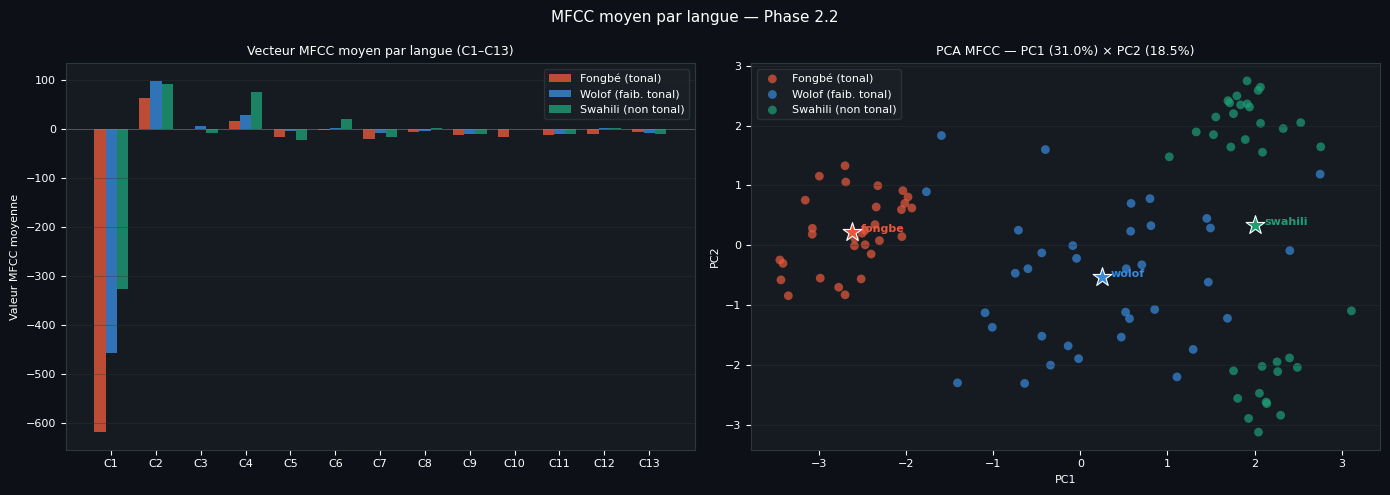


Variance expliquée PCA :
  PC1 : 31.0%
  PC2 : 18.5%
  Total (2 composantes) : 49.5%


In [13]:
# ── 2.4a  MFCC moyen par langue (diagramme radar) ────────────────────────────

cols_mfcc_ok = [c for c in COLS_MFCC if c in df.columns]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.patch.set_facecolor(DARK_BG)
fig.suptitle('MFCC moyen par langue — Phase 2.2', color='white', fontsize=11)

# ── Graphique 1 : MFCC moyens (barres groupées) ──────────────────────────────
ax = axes[0]
x  = np.arange(len(cols_mfcc_ok))
w  = 0.25

for j, lang in enumerate(LANGUES):
    moy = df[df['langue'] == lang][cols_mfcc_ok].mean().values
    ax.bar(x + j*w, moy, w, label=LABELS[lang],
           color=COULEURS[lang], alpha=0.8, linewidth=0)

ax.set_xticks(x + w)
ax.set_xticklabels([f'C{i}' for i in range(1, len(cols_mfcc_ok)+1)],
                    color='white', fontsize=7.5)
ax.axhline(0, color='white', linewidth=0.5, alpha=0.3)
ax.legend(facecolor='#1C2128', edgecolor=GRID_COL, labelcolor='white', fontsize=8)
style_ax(ax, title='Vecteur MFCC moyen par langue (C1–C13)',
         ylabel='Valeur MFCC moyenne')

# ── Graphique 2 : PCA sur les vecteurs MFCC ──────────────────────────────────
ax2 = axes[1]
df_ok = df.dropna(subset=cols_mfcc_ok)
X_mfcc = df_ok[cols_mfcc_ok].values
y_lang = df_ok['langue'].values

scaler = StandardScaler()
X_sc   = scaler.fit_transform(X_mfcc)
pca    = PCA(n_components=2)
X_pca  = pca.fit_transform(X_sc)

for lang in LANGUES:
    mask = y_lang == lang
    ax2.scatter(X_pca[mask, 0], X_pca[mask, 1],
                color=COULEURS[lang], alpha=0.7, s=40,
                label=LABELS[lang], edgecolors='none')
    # Centroïde
    cx, cy = X_pca[mask, 0].mean(), X_pca[mask, 1].mean()
    ax2.scatter(cx, cy, color=COULEURS[lang], s=200,
                marker='*', edgecolors='white', linewidth=0.8, zorder=5)
    ax2.text(cx + 0.1, cy, lang, color=COULEURS[lang], fontsize=8, fontweight='bold')

ax2.legend(facecolor='#1C2128', edgecolor=GRID_COL, labelcolor='white', fontsize=8)
style_ax(ax2,
         title=f'PCA MFCC — PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%) '
               f'× PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)',
         xlabel='PC1', ylabel='PC2')

plt.tight_layout()
sauver(fig, 'mfcc_comparatif.png')
plt.show()

print(f'\nVariance expliquée PCA :')
print(f'  PC1 : {pca.explained_variance_ratio_[0]*100:.1f}%')
print(f'  PC2 : {pca.explained_variance_ratio_[1]*100:.1f}%')
print(f'  Total (2 composantes) : {sum(pca.explained_variance_ratio_)*100:.1f}%')

In [14]:
# ── 2.4b  Distances MFCC pour les paires minimales fongbé ────────────────────
from scipy.spatial.distance import euclidean, cosine

paires_min = df[df['paire_minimale'] == 'oui']

if paires_min.empty:
    print(' Aucune paire minimale dans le CSV')
else:
    print('Distances MFCC — paires minimales vs mots non-apparentés\n')
    print(f'{"Paire":<20} {"Membres":<30} {"Dist. eucl.":>12} {"Dist. cos.":>12}')
    print('─' * 78)

    dist_paires, dist_non_app = [], []

    for pid, grp in paires_min.groupby('id_paire'):
        if len(grp) != 2:
            continue
        grp = grp.sort_values('ton_patron',
                               key=lambda x: x.map({'H':0,'B':1}).fillna(2))
        v1 = grp.iloc[0][cols_mfcc_ok].values.astype(float)
        v2 = grp.iloc[1][cols_mfcc_ok].values.astype(float)
        if np.any(np.isnan(v1)) or np.any(np.isnan(v2)):
            continue
        d_euc = euclidean(v1, v2)
        d_cos = cosine(v1, v2)
        dist_paires.append((d_euc, d_cos))
        m1 = grp.iloc[0].get('transcription_ortho', grp.iloc[0]['id'])
        m2 = grp.iloc[1].get('transcription_ortho', grp.iloc[1]['id'])
        print(f'{pid:<20} {str(m1)+" vs "+str(m2):<30} {d_euc:>12.2f} {d_cos:>12.4f}')

    # Distances entre mots NON apparentés (fongbé vs swahili)
    fon_vecs = df[df['langue']=='fongbe'][cols_mfcc_ok].dropna().values
    sw_vecs  = df[df['langue']=='swahili'][cols_mfcc_ok].dropna().values
    for i in range(min(5, len(fon_vecs), len(sw_vecs))):
        d_euc = euclidean(fon_vecs[i], sw_vecs[i])
        d_cos = cosine(fon_vecs[i], sw_vecs[i])
        dist_non_app.append((d_euc, d_cos))

    if dist_paires and dist_non_app:
        moy_p_euc = np.mean([d[0] for d in dist_paires])
        moy_n_euc = np.mean([d[0] for d in dist_non_app])
        moy_p_cos = np.mean([d[1] for d in dist_paires])
        moy_n_cos = np.mean([d[1] for d in dist_non_app])
        print('─' * 78)
        print(f'  Moy. paires minimales     : eucl.={moy_p_euc:.2f}  cos.={moy_p_cos:.4f}')
        print(f'  Moy. mots non-apparentés  : eucl.={moy_n_euc:.2f}  cos.={moy_n_cos:.4f}')
        ratio = moy_n_euc / moy_p_euc if moy_p_euc > 0 else 0
        print(f'\n  Ratio distances (non-app / paires) : {ratio:.2f}x')
        if ratio < 2:
            print('  → MFCC peu discriminants pour les tons (ratio < 2) ')
        else:
            print('  → MFCC distinguent mieux les mots différents que les paires tonales ')

Distances MFCC — paires minimales vs mots non-apparentés

Paire                Membres                         Dist. eucl.   Dist. cos.
──────────────────────────────────────────────────────────────────────────────
pair_faudio_009      audio_009 vs audio_010                18.08       0.0003
pair_faudio_011      audio_011 vs audio_012                35.69       0.0008
pair_faudio_012      audio_013 vs audio_014                33.64       0.0005
pair_faudio_013      audio_015 vs audio_016                20.32       0.0002
pair_faudio_022      audio_022 vs audio_023                36.22       0.0005
pair_faudio_025      audio_025 vs audio_026                19.48       0.0002
──────────────────────────────────────────────────────────────────────────────
  Moy. paires minimales     : eucl.=27.24  cos.=0.0004
  Moy. mots non-apparentés  : eucl.=323.83  cos.=0.0416

  Ratio distances (non-app / paires) : 11.89x
  → MFCC distinguent mieux les mots différents que les paires tonales 


## 2.5 Classification automatique SVM + KNN

In [15]:
# ── Préparation du jeu de données ─────────────────────────────────────────────
cols_ok = [c for c in COLS_SVM if c in df.columns]
df_clf  = df.dropna(subset=cols_ok + ['langue']).copy()

X = df_clf[cols_ok].values
y = df_clf['langue'].values

# Normalisation (indispensable pour SVM)
scaler = StandardScaler()
X_sc   = scaler.fit_transform(X)

print(f'Jeu de données : {X_sc.shape[0]} énoncés × {X_sc.shape[1]} features')
print(f'Classes : {dict(zip(*np.unique(y, return_counts=True)))}\n')

# ── Validation croisée 5-fold ─────────────────────────────────────────────────
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

classifieurs = {
    'SVM (RBF)':  SVC(kernel='rbf',    C=10, gamma='scale', random_state=42),
    'SVM (Lin.)': SVC(kernel='linear', C=1,                 random_state=42),
    'KNN (k=5)':  KNeighborsClassifier(n_neighbors=5),
}

print(f'{"Classifieur":<15} {"Accuracy":>10} {"F1-macro":>10}')
print('─' * 40)

resultats = {}
for nom, clf in classifieurs.items():
    y_pred = cross_val_predict(clf, X_sc, y, cv=cv)
    acc    = (y_pred == y).mean()
    f1     = float(pd.Series(
        classification_report(y, y_pred, output_dict=True)['macro avg']['f1-score']
    ))
    resultats[nom] = {'y_pred': y_pred, 'acc': acc, 'f1': f1}
    print(f'{nom:<15} {acc*100:>9.1f}% {f1*100:>9.1f}%')

# Meilleur classifieur
meilleur = max(resultats, key=lambda k: resultats[k]['acc'])
print(f'\n→ Meilleur : {meilleur} (accuracy = {resultats[meilleur]["acc"]*100:.1f}%)')

Jeu de données : 100 énoncés × 18 features
Classes : {'fongbe': 30, 'swahili': 35, 'wolof': 35}

Classifieur       Accuracy   F1-macro
────────────────────────────────────────
SVM (RBF)            98.0%      97.9%
SVM (Lin.)           97.0%      96.9%
KNN (k=5)            96.0%      95.9%

→ Meilleur : SVM (RBF) (accuracy = 98.0%)


  Figure → figures_phase2/matrice_confusion_svm.png


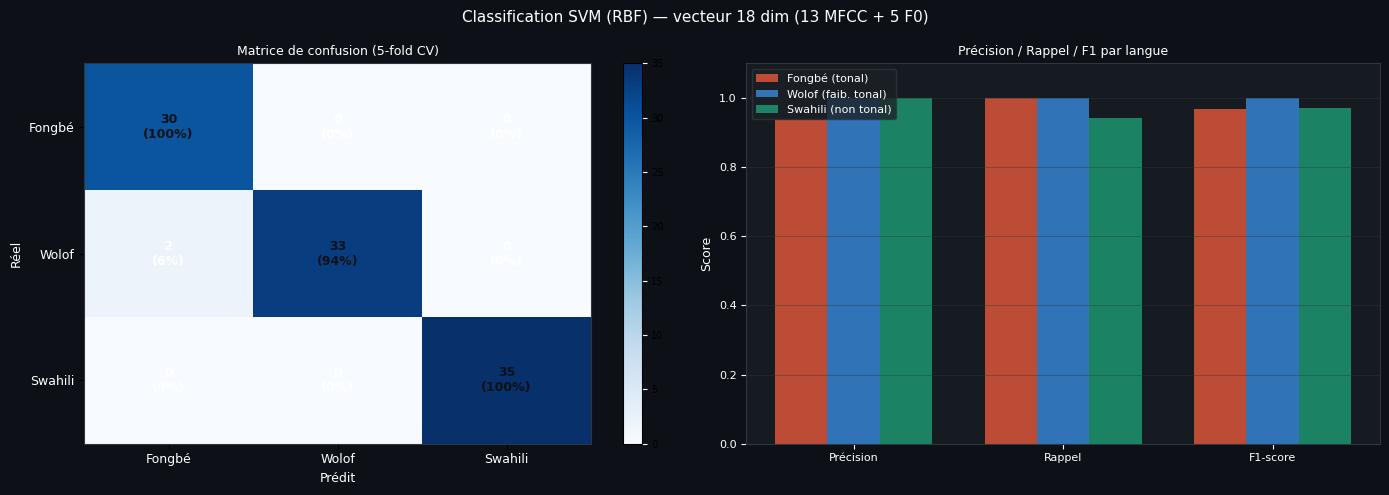


Rapport complet :

              precision    recall  f1-score   support

      Fongbé       0.94      1.00      0.97        30
       Wolof       1.00      1.00      1.00        35
     Swahili       1.00      0.94      0.97        35

    accuracy                           0.98       100
   macro avg       0.98      0.98      0.98       100
weighted avg       0.98      0.98      0.98       100



In [16]:
# ── Matrice de confusion (meilleur classifieur) ───────────────────────────────
y_pred_best = resultats[meilleur]['y_pred']
cm = confusion_matrix(y, y_pred_best, labels=LANGUES)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.patch.set_facecolor(DARK_BG)
fig.suptitle(f'Classification {meilleur} — vecteur 18 dim (13 MFCC + 5 F0)',
             color='white', fontsize=11)

# Matrice de confusion
ax = axes[0]
im = ax.imshow(cm, cmap='Blues', aspect='auto')
plt.colorbar(im, ax=ax).ax.yaxis.set_tick_params(color='white', labelsize=7)
tick_labels = ['Fongbé', 'Wolof', 'Swahili']
ax.set_xticks([0,1,2]); ax.set_xticklabels(tick_labels, color='white', fontsize=9)
ax.set_yticks([0,1,2]); ax.set_yticklabels(tick_labels, color='white', fontsize=9)
ax.set_xlabel('Prédit', color='white', fontsize=9)
ax.set_ylabel('Réel', color='white', fontsize=9)
for i in range(3):
    for j in range(3):
        val = cm[i, j]
        total = cm[i].sum()
        pct   = val/total*100 if total > 0 else 0
        col   = 'white' if cm[i,j] < cm.max()*0.6 else '#0D1117'
        ax.text(j, i, f'{val}\n({pct:.0f}%)', ha='center', va='center',
                color=col, fontsize=9, fontweight='bold')
ax.set_facecolor(AX_BG)
for sp in ax.spines.values(): sp.set_edgecolor(GRID_COL)
ax.set_title('Matrice de confusion (5-fold CV)', color='white', fontsize=9)

# Rapport de classification
ax2 = axes[1]
ax2.set_facecolor(AX_BG)
for sp in ax2.spines.values(): sp.set_edgecolor(GRID_COL)
report = classification_report(y, y_pred_best, target_names=tick_labels,
                                output_dict=True)
metriques_clf = ['precision', 'recall', 'f1-score']
x_pos = np.arange(len(metriques_clf))
w = 0.25
for j, lang_label in enumerate(tick_labels):
    vals_clf = [report[lang_label][m] for m in metriques_clf]
    lang_key = LANGUES[j]
    ax2.bar(x_pos + j*w, vals_clf, w,
            color=COULEURS[lang_key], alpha=0.8, label=LABELS[lang_key])
ax2.set_xticks(x_pos + w)
ax2.set_xticklabels(['Précision', 'Rappel', 'F1-score'], color='white', fontsize=9)
ax2.set_ylim(0, 1.1)
ax2.set_ylabel('Score', color='white', fontsize=9)
ax2.legend(facecolor='#1C2128', edgecolor=GRID_COL, labelcolor='white', fontsize=8)
ax2.tick_params(colors='white', labelsize=8)
ax2.grid(axis='y', color=GRID_COL, linewidth=0.4, alpha=0.7)
ax2.set_title('Précision / Rappel / F1 par langue', color='white', fontsize=9)

plt.tight_layout()
sauver(fig, 'matrice_confusion_svm.png')
plt.show()

print(f'\nRapport complet :\n')
print(classification_report(y, y_pred_best, target_names=tick_labels))

Calcul des features les plus discriminantes...
  Figure → figures_phase2/feature_importance.png


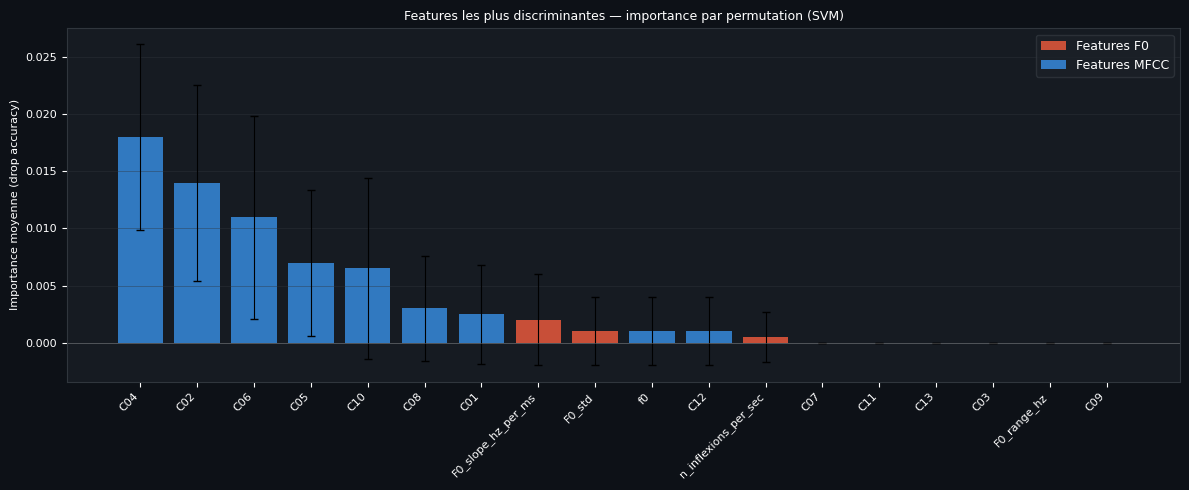


Top 5 features discriminantes :
  1. C04                  importance = 0.0180 ± 0.0081
  2. C02                  importance = 0.0140 ± 0.0086
  3. C06                  importance = 0.0110 ± 0.0089
  4. C05                  importance = 0.0070 ± 0.0064
  5. C10                  importance = 0.0065 ± 0.0079


In [17]:
# ── Features les plus discriminantes (importance par permutation) ─────────────
from sklearn.svm import SVC
from sklearn.inspection import permutation_importance

print('Calcul des features les plus discriminantes...')

# Entraîner sur tout le corpus pour l'importance
clf_best = SVC(kernel='rbf', C=10, gamma='scale', random_state=42)
clf_best.fit(X_sc, y)

perm = permutation_importance(clf_best, X_sc, y,
                               n_repeats=20, random_state=42, n_jobs=-1)

# Trier par importance décroissante
idx_sort = np.argsort(perm.importances_mean)[::-1]
feat_names = [c.replace('_mean','').replace('mfcc_','C').replace('f0_','F0_')
              for c in cols_ok]

fig, ax = plt.subplots(figsize=(12, 5))
fig.patch.set_facecolor(DARK_BG)

colors_bar = ['#E8593C' if 'F0' in feat_names[i] or 'slope' in cols_ok[i]
              or 'inflexion' in cols_ok[i]
              else '#378ADD'
              for i in idx_sort]

ax.bar(range(len(idx_sort)),
       perm.importances_mean[idx_sort],
       yerr=perm.importances_std[idx_sort],
       color=colors_bar, alpha=0.85, capsize=3, error_kw={'color':'white','linewidth':0.8})
ax.set_xticks(range(len(idx_sort)))
ax.set_xticklabels([feat_names[i] for i in idx_sort],
                    rotation=45, ha='right', color='white', fontsize=8)
ax.axhline(0, color='white', linewidth=0.5, alpha=0.3)
style_ax(ax, title='Features les plus discriminantes — importance par permutation (SVM)',
         ylabel='Importance moyenne (drop accuracy)')

# Légende couleurs
p1 = mpatches.Patch(facecolor='#E8593C', alpha=0.85, label='Features F0')
p2 = mpatches.Patch(facecolor='#378ADD', alpha=0.85, label='Features MFCC')
ax.legend(handles=[p1, p2], facecolor='#1C2128', edgecolor=GRID_COL,
          labelcolor='white', fontsize=9)

plt.tight_layout()
sauver(fig, 'feature_importance.png')
plt.show()

print(f'\nTop 5 features discriminantes :')
for rank, i in enumerate(idx_sort[:5], 1):
    print(f'  {rank}. {feat_names[i]:<20} importance = {perm.importances_mean[i]:.4f} '
          f'± {perm.importances_std[i]:.4f}')

## 2.6 Résumé — Synthèse Phase 2

In [18]:
print('═' * 65)
print('  SYNTHÈSE PHASE 2 — à recopier dans le rapport')
print('═' * 65)

# Récupérer les valeurs clés
for lang in LANGUES:
    sub = df[df['langue'] == lang]
    print(f'\n  {lang.upper()} ({len(sub)} énoncés)')
    for col in ['f0_mean','f0_std','f0_range_hz','f0_range_st',
                'f0_slope_hz_per_ms','n_inflexions_per_sec']:
        if col in sub.columns:
            v = sub[col].dropna()
            print(f'    {col:<28}: {v.mean():>8.2f} ± {v.std():.2f}')

print(f'\n  Classification SVM (18 dim, 5-fold CV) :')
for nom, res in resultats.items():
    print(f'    {nom:<15}: accuracy = {res["acc"]*100:.1f}%  F1 = {res["f1"]*100:.1f}%')

print(f'\n  Figures générées dans {DOSSIER_FIG}/ :')
for f in sorted(DOSSIER_FIG.glob('*.png')):
    print(f'    {f.name}')

print('\n' + '═' * 65)

═════════════════════════════════════════════════════════════════
  SYNTHÈSE PHASE 2 — à recopier dans le rapport
═════════════════════════════════════════════════════════════════

  FONGBE (30 énoncés)
    f0_mean                     :   231.83 ± 24.37
    f0_std                      :    39.26 ± 17.97
    f0_range_hz                 :   140.51 ± 59.81
    f0_range_st                 :     9.95 ± 3.82
    f0_slope_hz_per_ms          :    -0.02 ± 0.16
    n_inflexions_per_sec        :     9.06 ± 4.22

  WOLOF (35 énoncés)
    f0_mean                     :   157.99 ± 46.54
    f0_std                      :    26.73 ± 22.80
    f0_range_hz                 :   114.29 ± 73.84
    f0_range_st                 :    12.01 ± 6.00
    f0_slope_hz_per_ms          :    -0.01 ± 0.06
    n_inflexions_per_sec        :    11.70 ± 5.05

  SWAHILI (35 énoncés)
    f0_mean                     :   187.64 ± 44.78
    f0_std                      :    26.56 ± 14.30
    f0_range_hz                 :   129.73 